# Predicting Length of Stay (LOS) for Hospital Inpatients
### A Machine Learning Regression Study on the NYS SPARCS Hospital Inpatient Discharge Dataset
**Subject:** Machine Learning | **Guide:** *Prof. Nisa A K* | **Authors:** *Ann Nova (B25CTA19),Gopika Prasad (B25CTA35),Charaulatha V (B25CTA28), Anusree K (B25CTA20),Hisana Thasnim (B25CTA86)*
**Branch:** *Computer Science and Engineering* | **Institution:** TKM College of Engineering 




## Table of Contents

1. [Problem Statement & Objectives](#1.-Problem-Statement-&-Objectives)
2. [Dataset Description](#2.-Dataset-Description)
3. [Environment Setup & Data Loading](#3.-Environment-Setup-&-Data-Loading)
4. [Exploratory Data Analysis (EDA)](#4.-Exploratory-Data-Analysis-(EDA))
5. [Feature Selection & Leakage Control](#5.-Feature-Selection-&-Leakage-Control)
6. [Train–Test Split](#6.-Train–Test-Split)
7. [Missing Value Handling (Post-Split)](#7.-Missing-Value-Handling-(Post-Split))
8. [Feature Refinement — Removing Redundant & Leaky Columns](#8.-Feature-Refinement)
9. [Final Preprocessing Pipeline](#9.-Final-Preprocessing-Pipeline)
10. [Model Building & Evaluation](#10.-Model-Building-&-Evaluation)
    - 10.1 Linear Regression (Baseline)
    - 10.2 Random Forest Regressor
    - 10.3 XGBoost Regressor
    - 10.4 CatBoost Regressor (Native Categorical Handling)
11. [Model Comparison](#11.-Model-Comparison)
12. [Diagnostic Visualization](#12.-Diagnostic-Visualization)
13. [Feature Importance Analysis](#13.-Feature-Importance-Analysis)
14. [Results & Discussion](#14.-Results-&-Discussion)
15. [Limitations](#15.-Limitations)
16. [Conclusion & Future Work](#16.-Conclusion-&-Future-Work)
17. [References](#17.-References)


## 1. Problem Statement & Objectives

**Length of Stay (LOS)** :days a patient remains admitted, drives bed planning, staffing, and
cost estimation. This project predicts LOS at **admission time**, using only information
realistically available then (diagnosis, procedure, demographics, severity), not discharge-time
fields like billing totals.

**Goals:**
1. EDA on data quality, missingness, cardinality.
2. Build a clean, leakage-free feature set.
3. Train & compare **Linear Regression → Random Forest → XGBoost → CatBoost**.
4. Evaluate using **MAE, RMSE, R²**.
5. Interpret the best model via feature importance.


## 2. Dataset Description

Hospital inpatient discharge data in the from of **NYS SPARCS** .

Each row = one hospitalization episode.

| Category | Example Columns |
|---|---|
| Target | `Length of Stay` |
| Demographics | `Age Group`, `Gender`, `Race`, `Ethnicity`, `Zip Code` |
| Admission | `Type of Admission`, `Emergency Department Indicator` |
| Clinical coding | `CCSR Diagnosis/Procedure Code & Description` |
| APR severity group | `APR DRG/MDC/Severity/Risk of Mortality` |
| Facility | `Facility Name`, `Facility Id`, `Hospital County` |
| Financial (discharge-time) | `Total Charges`, `Total Costs` |
| Other | `Birth Weight`, `Patient Disposition`, `Discharge Year` |

Fields only known **after** discharge (`Total Charges/Costs`, `Patient Disposition`, APR
severity codes) cause **target leakage** if used as predictors are removed in Sections 5 & 8.


## 3. Environment Setup & Data Loading

Developed in **Google Colab**; dataset stored on Google Drive.
**Libraries:** `pandas`, `numpy`, `scikit-learn`, `xgboost`, `catboost`, `matplotlib`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ml project/dataset.csv')


/tmp/ipykernel_2407/2440508507.py:3: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/ml project/dataset.csv')


In [ ]:
df


,Health Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Hudson Valley,Westchester,5957001.0,1139.0,WESTCHESTER MEDICAL CENTER,0-17,OOS,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,46814.00,6772.07
1,New York City,Queens,7003001.0,1628.0,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,13490.00,15464.30
2,New York City,New York,7002054.0,1458.0,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,...,Moderate,Moderate,Medical,Medicare,Private Health Insurance,NaN,NaN,Y,49503.16,9324.77
3,New York City,New York,7002054.0,1464.0,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,...,Minor,Minor,Medical,Private Health Insurance,NaN,NaN,2700,Y,27827.66,7304.27
4,New York City,New York,7002032.0,1466.0,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicare,NaN,NaN,NaN,Y,32798.29,7948.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196732,New York City,New York,7002024.0,1456.0,MOUNT SINAI HOSPITAL,70 or Older,111,F,Multi-racial,Not Span/Hispanic,...,Moderate,Moderate,Surgical,Medicare,Medicare,Medicaid,NaN,N,59727.81,17084.60
2196733,Central NY,Jefferson,2238700.0,379.0,CARTHAGE AREA HOSPITAL INC,18-29,136,F,White,Not Span/Hispanic,...,Minor,Minor,Surgical,Federal/State/Local/VA,NaN,NaN,NaN,N,25474.57,43365.68
2196734,New York City,Kings,7001016.0,1301.0,KINGS COUNTY HOSPITAL CENTER,30-49,112,F,Black/African American,Unknown,...,Moderate,Minor,Surgical,Medicaid,NaN,NaN,NaN,N,51617.21,28211.54
2196735,Long Island,Nassau,7002053.0,511.0,NYU LANGONE HOSPITAL-LONG ISLAND,30-49,117,F,White,Not Span/Hispanic,...,Major,Moderate,Medical,Blue Cross/Blue Shield,NaN,NaN,NaN,N,60404.55,19568.72


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (2196737, 33)


,Health Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Hudson Valley,Westchester,5957001.0,1139.0,WESTCHESTER MEDICAL CENTER,0-17,OOS,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,46814.00,6772.07
1,New York City,Queens,7003001.0,1628.0,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,13490.00,15464.30
2,New York City,New York,7002054.0,1458.0,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,...,Moderate,Moderate,Medical,Medicare,Private Health Insurance,NaN,NaN,Y,49503.16,9324.77
3,New York City,New York,7002054.0,1464.0,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,...,Minor,Minor,Medical,Private Health Insurance,NaN,NaN,2700,Y,27827.66,7304.27
4,New York City,New York,7002032.0,1466.0,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicare,NaN,NaN,NaN,Y,32798.29,7948.10


---

## 4. Exploratory Data Analysis (EDA)

Profiling the raw data's schema, missingness, cardinality, and target behaviour before modeling.

### 4.1 Schema Check
Column names & dtypes reveals `Length of Stay` and `Birth Weight` were read as text and need conversion.

In [ ]:
# 1. Column names and data types
print(df.dtypes)

Health Service Area                     object
Hospital County                         object
Operating Certificate Number           float64
Permanent Facility Id                  float64
Facility Name                           object
Age Group                               object
Zip Code                                object
Gender                                  object
Race                                    object
Ethnicity                               object
Length of Stay                          object
Type of Admission                       object
Patient Disposition                     object
Discharge Year                           int64
CCSR Diagnosis Code                     object
CCSR Diagnosis Description              object
CCSR Procedure Code                     object
CCSR Procedure Description              object
APR DRG Code                             int64
APR DRG Description                     object
APR MDC Code                             int64
APR MDC Descr

### 4.2 Missing Value Audit
Column-wise missing count/percentage, sorted descending.

In [ ]:
# 2. Missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print(missing_table)

                                     Missing Count  Missing %
Birth Weight                               1988915      90.54
Payment Typology 3                         1956699      89.07
Payment Typology 2                         1204408      54.83
CCSR Procedure Description                  643764      29.31
CCSR Procedure Code                         643764      29.31
Zip Code                                     41972       1.91
Health Service Area                           5295       0.24
Permanent Facility Id                         5295       0.24
Hospital County                               5295       0.24
Operating Certificate Number                  5295       0.24
Payment Typology 1                             227       0.01
Type of Admission                                0       0.00
Ethnicity                                        0       0.00
Race                                             0       0.00
Facility Name                                    0       0.00
Gender  

### 4.3 Cardinality Check
Unique-value counts per column, flags low-cardinality categoricals vs. high-cardinality identifiers.

In [ ]:
# 3. Number of unique values in each column
unique_values = df.nunique().sort_values()

print(unique_values)

Discharge Year                               1
Emergency Department Indicator               2
APR Medical Surgical Description             3
Gender                                       3
Race                                         4
Ethnicity                                    4
Age Group                                    5
APR Severity of Illness Code                 5
APR Severity of Illness Description          5
APR Risk of Mortality                        5
Type of Admission                            6
Health Service Area                          8
Payment Typology 2                           9
Payment Typology 3                           9
Payment Typology 1                           9
Patient Disposition                         19
APR MDC Description                         26
APR MDC Code                                26
Zip Code                                    50
Hospital County                             57
Length of Stay                             120
Birth Weight 

### 4.4 Target Variable — `Length of Stay`
Arrives as text with a top-coded `"120+"` bucket.

In [ ]:
print(df["Length of Stay"].value_counts().sort_index())

Length of Stay
1      392917
10      41454
100        69
101        72
102        62
        ...  
95         89
96         71
97         85
98         94
99         75
Name: count, Length: 120, dtype: int64


In [ ]:
print("Number of unique Length of Stay values:",
      df["Length of Stay"].nunique())

print("\nData type:", df["Length of Stay"].dtype)

Number of unique Length of Stay values: 120

Data type: object


In [ ]:
print(df["Length of Stay"].unique())

['1' '2' '3' '8' '9' '5' '4' '28' '6' '32' '48' '7' '22' '18' '13' '39'
 '11' '120+' '63' '114' '70' '80' '31' '12' '21' '26' '77' '74' '10' '15'
 '14' '88' '52' '24' '72' '23' '16' '17' '42' '20' '19' '25' '36' '51'
 '41' '29' '38' '37' '27' '119' '30' '35' '94' '83' '43' '33' '45' '34'
 '47' '71' '44' '57' '60' '61' '40' '68' '113' '58' '54' '53' '69' '78'
 '50' '91' '55' '90' '49' '65' '62' '64' '105' '89' '59' '102' '85' '46'
 '67' '104' '79' '99' '117' '66' '100' '93' '92' '109' '86' '111' '97'
 '95' '75' '96' '115' '73' '56' '116' '84' '76' '87' '101' '103' '81'
 '118' '82' '112' '110' '108' '98' '106' '107']


`"120+"` → `120`, cast to integer.

In [ ]:
# Convert Length of Stay to numeric
df["Length of Stay"] = df["Length of Stay"].replace("120+", "120").astype(int)

print(df["Length of Stay"].dtype)
print(df["Length of Stay"].describe())

int64
count    2.196737e+06
mean     5.810259e+00
std      8.826429e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      1.200000e+02
Name: Length of Stay, dtype: float64


### 4.5 `Birth Weight`
Only meaningful for infant admissions, expected missing/`"UNKN"` for adults. Checked via cross tab against `Age Group`.

In [ ]:
print(df["Birth Weight"].value_counts(dropna=False).head(30))

Birth Weight
NaN       1988915
3200         9156
3300         9076
3100         8817
3400         8768
3200.0       8271
3000         7966
3300.0       7959
3500         7684
3400.0       7596
3100.0       7440
2900         6771
3500.0       6728
3000.0       6694
3600         6644
2800         5822
2900.0       5730
3600.0       5713
3700         5574
2800.0       4736
3700.0       4664
2700         4537
3800         4431
2700.0       3717
2600         3630
3800.0       3546
3900         3464
2500         2807
2600.0       2783
3900.0       2647
Name: count, dtype: int64


In [ ]:
print(df["Birth Weight"].dropna().unique()[:50])

['2700' '3300' '3900' '3000' '3200' '4300' '3600' '3100' '3700' '4600'
 '3400' '3500' '4500' '4000' '3800' '2900' '2600' '2800' '4400' '4100'
 '2500' '4200' '2300' '1900' '1500' '4800' '4900' '5100' '2200' '5000'
 '2000' '2100' '2400' '500' '1000' '900' '1600' '700' '800' '1700' '1400'
 '4700' 'UNKN' '1300' '1800' '1100' '1200' '400' '600' '7500']


In [ ]:
birth_weight_by_age = pd.crosstab(
    df["Age Group"],
    df["Birth Weight"].isna(),
    normalize="index"
).round(4)

print(birth_weight_by_age)

Birth Weight   False   True 
Age Group                   
0-17          0.6883  0.3117
18-29         0.0000  1.0000
30-49         0.0000  1.0000
50-69         0.0000  1.0000
70 or Older   0.0000  1.0000


In [ ]:
print(df["Birth Weight"].value_counts(dropna=False).tail(20))

Birth Weight
5200.0    6
5400.0    5
5500      3
5600      3
7500      2
8000      2
6100      2
5700      2
9000      2
7700.0    1
7100.0    1
5600.0    1
5500.0    1
7600.0    1
9000.0    1
6900.0    1
7900      1
7200.0    1
6000.0    1
6500.0    1
Name: count, dtype: int64


*(Re-checked against the tail of the value counts.)*

In [ ]:
birth_weight_by_age = pd.crosstab(
    df["Age Group"],
    df["Birth Weight"].isna(),
    normalize="index"
).round(4)

print(birth_weight_by_age)


Birth Weight   False   True 
Age Group                   
0-17          0.6883  0.3117
18-29         0.0000  1.0000
30-49         0.0000  1.0000
50-69         0.0000  1.0000
70 or Older   0.0000  1.0000


`"UNKN"` → true missing, column coerced to numeric. Since missingness itself is informative
(≈ non-newborn), a binary `Birth Weight Missing` indicator is added instead of silently imputing.

In [ ]:
# Replace unknown values with missing
df["Birth Weight"] = df["Birth Weight"].replace("UNKN", pd.NA)

# Convert to numeric
df["Birth Weight"] = pd.to_numeric(
    df["Birth Weight"],
    errors="coerce"
)

print(df["Birth Weight"].dtype)

float64


In [ ]:
df["Birth Weight Missing"] = df["Birth Weight"].isna().astype(int)

:::`Length of Stay` conversion re-applied on `df` for traceability.

In [ ]:
df["Length of Stay"] = (
    df["Length of Stay"]
    .replace("120+", "120")
    .astype(int)
)

print(df["Length of Stay"].dtype)

int64


In [ ]:
print(df["Length of Stay"].describe())

count    2.196737e+06
mean     5.810259e+00
std      8.826429e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      1.200000e+02
Name: Length of Stay, dtype: float64


### 4.6 Categorical Field Profiling
Cardinality and top categories for `Patient Disposition`, the APR family, and CCSR procedure
fields informs the leakage/redundancy decisions in Sections 5 & 8.

In [ ]:
cols_to_check = [
    "Patient Disposition",
    "APR DRG Code",
    "APR DRG Description",
    "APR MDC Code",
    "APR MDC Description",
    "APR Severity of Illness Code",
    "APR Severity of Illness Description",
    "APR Risk of Mortality",
    "APR Medical Surgical Description",
    "CCSR Procedure Code",
    "CCSR Procedure Description"
]

for col in cols_to_check:
    print("\n" + "="*70)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


Patient Disposition
Unique values: 19
Patient Disposition
Home or Self Care                       1441830
Home w/ Home Health Services             299705
Skilled Nursing Home                     211258
Left Against Medical Advice               57701
Expired                                   54460
Short-term Hospital                       38487
Inpatient Rehabilitation Facility         35860
Hospice - Home                            11241
Psychiatric Hospital or Unit of Hosp       9954
Hospice - Medical Facility                 9856
Name: count, dtype: int64

APR DRG Code
Unique values: 336
APR DRG Code
640    168494
720    144367
560    123398
194     60015
540     59419
139     33096
463     32638
137     30700
750     29639
45      27317
Name: count, dtype: int64

APR DRG Description
Unique values: 336
APR DRG Description
NEONATE BIRTH WEIGHT > 2499 GRAMS, NORMAL NEWBORN OR NEONATE WITH OTHER PROBLEM    168494
SEPTICEMIA AND DISSEMINATED INFECTIONS                                   

---

## 5. Feature Selection & Leakage Control

A modeling copy `df_model` is created. Four columns are dropped as leakage/non-predictive:

| Column | Reason |
|---|---|
| `Patient Disposition` | Known only at/after discharge |
| `Total Charges` | Scales directly with LOS — leakage proxy |
| `Total Costs` | Same leakage concern |
| `Discharge Year` | Near-constant, no signal |


In [ ]:
df_model = df.copy()

drop_cols = [
    "Patient Disposition",
    "Total Charges",
    "Total Costs",
    "Discharge Year"
]

df_model = df_model.drop(columns=drop_cols)

print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Shape: (2196737, 30)
['Health Service Area', 'Hospital County', 'Operating Certificate Number', 'Permanent Facility Id', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description', 'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Birth Weight Missing']


`Birth Weight` cleaning (Sec 4.5) repeated on `df_model` for a self-contained modeling frame.

In [ ]:
df_model["Birth Weight"] = df_model["Birth Weight"].replace("UNKN", pd.NA)

df_model["Birth Weight"] = pd.to_numeric(
    df_model["Birth Weight"],
    errors="coerce"
)

df_model["Birth Weight Missing"] = (
    df_model["Birth Weight"].isna().astype(int)
)

print(df_model["Birth Weight"].dtype)
print(df_model["Birth Weight"].isna().sum())

float64
1989037


Fresh missing-value summary on `df_model`.

In [ ]:
missing = df_model.isnull().sum()
missing_percent = (missing / len(df_model)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

print(missing_summary)

                              Missing Count  Missing %
Birth Weight                        1989037  90.545068
Payment Typology 3                  1956699  89.072975
Payment Typology 2                  1204408  54.827137
CCSR Procedure Code                  643764  29.305465
CCSR Procedure Description           643764  29.305465
Zip Code                              41972   1.910652
Health Service Area                    5295   0.241039
Operating Certificate Number           5295   0.241039
Hospital County                        5295   0.241039
Permanent Facility Id                  5295   0.241039
Payment Typology 1                      227   0.010334


### 5.1 Does Missing Procedure Info Carry Signal?
`CCSR Procedure Code` is missing for many records (no coded procedure). Checked against target and other clinical fields.

In [ ]:
# Check how much the target differs when procedure information is missing
print(
    df_model.groupby(
        df_model["CCSR Procedure Code"].isna()
    )["Length of Stay"].agg(["count", "mean", "median"])
)

                       count      mean  median
CCSR Procedure Code                           
False                1552973  6.370345     3.0
True                  643764  4.459145     3.0


LOS vs. `APR Severity of Illness Description` — higher severity → longer stays, a good sanity check.

In [ ]:
# Check LOS by APR severity
print(
    df_model.groupby("APR Severity of Illness Description")["Length of Stay"]
    .agg(["count", "mean", "median"])
)

                                      count       mean  median
APR Severity of Illness Description                           
Extreme                              183129  15.417760    10.0
Major                                573480   7.161057     5.0
Minor                                619207   3.003703     2.0
Moderate                             820465   4.841414     3.0
Undetermined                            456   2.903509     2.0


In [ ]:
print(
    df_model.groupby(
        df_model["CCSR Procedure Code"].isna()
    )["CCSR Diagnosis Code"]
    .nunique()
)

CCSR Procedure Code
False    473
True     462
Name: CCSR Diagnosis Code, dtype: int64


In [ ]:
print(
    df_model.groupby(
        df_model["CCSR Procedure Code"].isna()
    )["APR DRG Code"]
    .nunique()
)


CCSR Procedure Code
False    336
True     186
Name: APR DRG Code, dtype: int64


### 5.2 Facility Identifier Redundancy
`Operating Certificate Number`, `Permanent Facility Id`, `Facility Name` likely identify the same facility checked for redundancy.

In [ ]:
print(
    df_model[
        [
            "Operating Certificate Number",
            "Permanent Facility Id",
            "Facility Name"
        ]
    ].nunique()
)

Operating Certificate Number    158
Permanent Facility Id           205
Facility Name                   203
dtype: int64


In [ ]:
print(
    df_model[
        [
            "Operating Certificate Number",
            "Permanent Facility Id",
            "Facility Name"
        ]
    ].drop_duplicates().shape
)


(206, 3)


Confirmed redundant → numeric ID columns dropped, `Facility Name` retained.

In [ ]:
df_model = df_model.drop(columns=[
    "Operating Certificate Number",
    "Permanent Facility Id"
])

print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Shape: (2196737, 28)
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description', 'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Birth Weight Missing']


In [ ]:
print(df_model.dtypes)

Health Service Area                     object
Hospital County                         object
Facility Name                           object
Age Group                               object
Zip Code                                object
Gender                                  object
Race                                    object
Ethnicity                               object
Length of Stay                           int64
Type of Admission                       object
CCSR Diagnosis Code                     object
CCSR Diagnosis Description              object
CCSR Procedure Code                     object
CCSR Procedure Description              object
APR DRG Code                             int64
APR DRG Description                     object
APR MDC Code                             int64
APR MDC Description                     object
APR Severity of Illness Code             int64
APR Severity of Illness Description     object
APR Risk of Mortality                   object
APR Medical S

Columns partitioned into **numerical** and **categorical** groups for `ColumnTransformer`.

In [ ]:
target = "Length of Stay"

numerical_features = [
    "Birth Weight",
    "Birth Weight Missing"
]

categorical_features = [
    col for col in df_model.columns
    if col not in numerical_features + [target]
]

print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Numerical features:
['Birth Weight', 'Birth Weight Missing']

Number of categorical features: 25
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description', 'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Emergency Department Indicator']


## 6. Train–Test Split

**80/20 split**, `random_state=42`. Done **before** fitting any imputer/encoder, to prevent
test-set statistics leaking into preprocessing.

In [ ]:
X = df_model.drop(columns=["Length of Stay"])
y = df_model["Length of Stay"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2196737, 27)
y shape: (2196737,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1757389, 27)
X_test : (439348, 27)
y_train: (1757389,)
y_test : (439348,)


## 7. Missing Value Handling (Post-Split)

Categorical NAs filled with constant `"Missing"` on train/test independently a constant
substitution, so no leakage.

In [ ]:
# Make copies
X_train = X_train.copy()
X_test = X_test.copy()

# Fill missing categorical values
for col in categorical_features:
    X_train[col] = X_train[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

print("Missing categorical values in training set:",
      X_train[categorical_features].isna().sum().sum())

print("Missing categorical values in test set:",
      X_test[categorical_features].isna().sum().sum())

Missing categorical values in training set: 0
Missing categorical values in test set: 0


In [ ]:
print("Birth Weight missing in train:",
      X_train["Birth Weight"].isna().sum())

print("Birth Weight missing in test:",
      X_test["Birth Weight"].isna().sum())

print("Birth Weight Missing values:")
print(X_train["Birth Weight Missing"].value_counts())

Birth Weight missing in train: 1591034
Birth Weight missing in test: 398003
Birth Weight Missing values:
Birth Weight Missing
1    1591034
0     166355
Name: count, dtype: int64


## 8. Feature Refinement

An initial `ColumnTransformer` (first pass), superseded after two more pruning steps below.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### 8.1 Dropping Free-Text Description Columns
Paired code/description fields (e.g. `CCSR Diagnosis Code` ↔ `...Description`) — descriptions
are verbose, high-cardinality restatements of the codes. Dropped, codes kept.

In [ ]:
description_cols = [
    "CCSR Diagnosis Description",
    "CCSR Procedure Description",
    "APR DRG Description",
    "APR MDC Description",
    "APR Severity of Illness Description"
]

X_train_reduced = X_train.drop(columns=description_cols)
X_test_reduced = X_test.drop(columns=description_cols)

print("X_train shape:", X_train_reduced.shape)
print("X_test shape :", X_test_reduced.shape)
print("Remaining columns:")
print(X_train_reduced.columns.tolist())

X_train shape: (1757389, 22)
X_test shape : (439348, 22)
Remaining columns:
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Birth Weight Missing']


In [ ]:
categorical_features_reduced = [
    col for col in categorical_features
    if col not in description_cols
]

print("Categorical features:", len(categorical_features_reduced))
print(categorical_features_reduced)

Categorical features: 20
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'CCSR Diagnosis Code', 'CCSR Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Emergency Department Indicator']


### 8.2 Removing APR Severity-Grouping Codes (Leakage Risk)
APR DRG/MDC/Severity/Risk-of-Mortality fields are assigned using the *complete* encounter
record, so they proxy the outcome. Removed to keep the model honest about admission-time
availability.

In [ ]:
leakage_cols = [
    "CCSR Procedure Code",
    "APR DRG Code",
    "APR MDC Code",
    "APR Severity of Illness Code",
    "APR Risk of Mortality",
    "APR Medical Surgical Description"
]

X_train_final = X_train_reduced.drop(columns=leakage_cols)
X_test_final = X_test_reduced.drop(columns=leakage_cols)

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)
print("Final features:")
print(X_train_final.columns.tolist())


Final X_train shape: (1757389, 16)
Final X_test shape: (439348, 16)
Final features:
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'CCSR Diagnosis Code', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Birth Weight Missing']


In [ ]:
numerical_features_final = [
    "Birth Weight",
    "Birth Weight Missing"
]

categorical_features_final = [
    col for col in X_train_final.columns
    if col not in numerical_features_final
]

print("Numerical features:", numerical_features_final)
print("\nNumber of categorical features:", len(categorical_features_final))
print(categorical_features_final)

Numerical features: ['Birth Weight', 'Birth Weight Missing']

Number of categorical features: 14
['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'CCSR Diagnosis Code', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Emergency Department Indicator']


---

## 9. Final Preprocessing Pipeline

`ColumnTransformer` on `X_train_final` / `X_test_final`:
- **Numerical** (`Birth Weight`, `Birth Weight Missing`) → median imputation
- **Categorical** → constant `"Missing"` imputation + **one-hot encoding** (`handle_unknown="ignore"`)

`fit()` on train only, `transform()` on both — leakage-safe.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine numerical + categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features_final),
        ("cat", categorical_transformer, categorical_features_final)
    ]
)

print("Final preprocessing pipeline created successfully.")

Final preprocessing pipeline created successfully.


In [ ]:
preprocessor.fit(X_train_final)

print("Preprocessor fitted successfully.")

Preprocessor fitted successfully.


In [ ]:
X_train_processed = preprocessor.transform(X_train_final)
X_test_processed = preprocessor.transform(X_test_final)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (1757389, 854)
X_test_processed shape: (439348, 854)


In [ ]:
print("Train matrix type:", type(X_train_processed))
print("Test matrix type:", type(X_test_processed))

print("\nTrain matrix shape:", X_train_processed.shape)
print("Test matrix shape:", X_test_processed.shape)

print("\nTarget training shape:", y_train.shape)
print("Target test shape:", y_test.shape)

print("\nAny missing values in processed training data:",
      X_train_processed.data[
          ~__import__("numpy").isfinite(X_train_processed.data)
      ].size)

Train matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Test matrix type: <class 'scipy.sparse._csr.csr_matrix'>

Train matrix shape: (1757389, 854)
Test matrix shape: (439348, 854)

Target training shape: (1757389,)
Target test shape: (439348,)

Any missing values in processed training data: 0


---

## 10. Model Building & Evaluation

Four regressors, evaluated on the same held-out test set via **MAE, RMSE, R²**.
Tree ensembles (RF, XGBoost, CatBoost) train on a **200,000-row sample** for tractable Colab
runtime (documented limitation, see Sec 15).

### 10.1 Linear Regression (Baseline)
Simple baseline on the one-hot-encoded matrix.

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

print("Training Linear Regression...")

lr_model.fit(X_train_processed, y_train)

print("Linear Regression training complete.")

Training Linear Regression...
Linear Regression training complete.


In [ ]:
y_pred_lr = lr_model.predict(X_test_processed)

print("Predictions generated.")
print("First 10 predictions:")
print(y_pred_lr[:10])

Predictions generated.
First 10 predictions:
[ 6.72676374  0.71540463  5.04402075  2.7816065   1.75293872  6.18262751
  1.73521426  2.98019327 12.05633532  9.02964349]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-" * 35)
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Results
-----------------------------------
MAE  : 4.0588
RMSE : 8.0955
R²   : 0.1679


### 10.2 Random Forest Regressor
Bagged trees to capture non-linear interactions. `max_depth=15`, `min_samples_leaf=5` to limit overfitting.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Sample 200,000 training rows
sample_size = 200_000

X_rf = X_train_processed[:sample_size]
y_rf = y_train.iloc[:sample_size]

print("Random Forest training data:")
print("X:", X_rf.shape)
print("y:", y_rf.shape)

Random Forest training data:
X: (200000, 854)
y: (200000,)


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_rf, y_rf)

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


print("Random Forest Results")
print("-" * 35)
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
-----------------------------------
MAE  : 4.0424
RMSE : 8.1561
R²   : 0.1554


### 10.3 XGBoost Regressor
Gradient-boosted trees; typically stronger than RF on tabular data. Subsampling (`0.8`/`0.8`) for regularization.

In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
from xgboost import XGBRegressor

In [ ]:
sample_size = 200_000

X_xgb = X_train_processed[:sample_size]
y_xgb = y_train.iloc[:sample_size]

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_xgb, y_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("-----------------------------------")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost Results
-----------------------------------
MAE  : 3.8742
RMSE : 7.9807
R²   : 0.1914


### 10.4 CatBoost Regressor (Native Categorical Handling)
Consumes categorical columns natively (no one-hot), avoiding sparsity on high-cardinality codes.
A separate copy (`X_train_cb`, `X_test_cb`) is prepared.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [ ]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


Categoricals cast to string; `Birth Weight` median-imputed to match the other pipelines.

In [ ]:
X_train_cb = X_train_final.copy()
X_test_cb = X_test_final.copy()

In [ ]:
for col in categorical_features_final:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

In [ ]:
birth_weight_median = X_train_cb["Birth Weight"].median()

X_train_cb["Birth Weight"] = X_train_cb["Birth Weight"].fillna(birth_weight_median)
X_test_cb["Birth Weight"] = X_test_cb["Birth Weight"].fillna(birth_weight_median)

In [ ]:
print("Training shape:", X_train_cb.shape)
print("Testing shape :", X_test_cb.shape)

print("\nMissing values in training:")
print(X_train_cb.isna().sum().sum())

print("\nMissing values in testing:")
print(X_test_cb.isna().sum().sum())

Training shape: (1757389, 16)
Testing shape : (439348, 16)

Missing values in training:
0

Missing values in testing:
0


Trained on the same 200k-row sample, with `cat_features` passed explicitly.

In [ ]:
from catboost import CatBoostRegressor

sample_size = 200_000

X_cb_sample = X_train_cb.iloc[:sample_size]
y_cb_sample = y_train.iloc[:sample_size]

cat_features_indices = [
    X_cb_sample.columns.get_loc(col)
    for col in categorical_features_final
]

cat_model = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=50,
    thread_count=-1
)

cat_model.fit(
    X_cb_sample,
    y_cb_sample,
    cat_features=cat_features_indices
)

0:	learn: 8.7082794	total: 650ms	remaining: 3m 14s
50:	learn: 7.8640318	total: 35.6s	remaining: 2m 53s
100:	learn: 7.7805511	total: 1m 11s	remaining: 2m 21s
150:	learn: 7.7447566	total: 1m 44s	remaining: 1m 43s
200:	learn: 7.7076526	total: 2m 17s	remaining: 1m 7s
250:	learn: 7.6834778	total: 2m 48s	remaining: 33s
299:	learn: 7.6682578	total: 3m 22s	remaining: 0us


CatBoostRegressor(depth=8, iterations=300, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=50)

In [ ]:
y_pred_cat = cat_model.predict(X_test_cb)

In [ ]:
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost Results")
print("-----------------------------------")
print(f"MAE  : {mae_cat:.4f}")
print(f"RMSE : {rmse_cat:.4f}")
print(f"R²   : {r2_cat:.4f}")

CatBoost Results
-----------------------------------
MAE  : 3.7721
RMSE : 7.8920
R²   : 0.2092


## 11. Model Comparison

All four models' metrics side by side.

In [ ]:
import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

model_results

,Model,MAE,RMSE,R²
0,Linear Regression,4.058773,8.095512,0.167932
1,Random Forest,4.042428,8.156064,0.155438
2,XGBoost,3.874165,7.980731,0.191359


In [ ]:
model_results.loc[len(model_results)] = [
    "CatBoost",
    mae_cat,
    rmse_cat,
    r2_cat
]

model_results.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R²": "{:.4f}"
})

,Model,MAE,RMSE,R²
0,Linear Regression,4.0588,8.0955,0.1679
1,Random Forest,4.0424,8.1561,0.1554
2,XGBoost,3.8742,7.9807,0.1914
3,CatBoost,3.7721,7.8920,0.2092


## 12. Diagnostic Visualization

Actual vs. predicted LOS (CatBoost). Points on the diagonal = accurate; deviation shows where the model struggles (e.g. long stays).

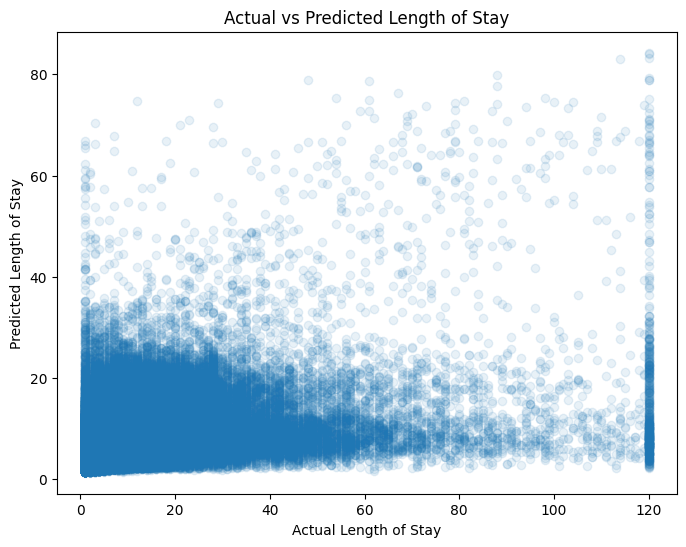

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cat, alpha=0.1)
plt.xlabel("Actual Length of Stay")
plt.ylabel("Predicted Length of Stay")
plt.title("Actual vs Predicted Length of Stay")
plt.show()

## 13. Feature Importance Analysis

CatBoost's built-in importances, top 10  moves the model from black-box to interpretable, surfacing key LOS drivers.

In [ ]:
feature_importance = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X_train_cb.columns,
    "Importance": feature_importance
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
9,CCSR Diagnosis Code,27.548446
13,Birth Weight,25.904525
2,Facility Name,13.428266
8,Type of Admission,10.164515
1,Hospital County,4.322196
3,Age Group,3.482314
10,Payment Typology 1,2.748448
6,Race,2.575093
11,Payment Typology 2,2.105147
0,Health Service Area,1.826708


In [ ]:
importance_df.head(10)

,Feature,Importance
9,CCSR Diagnosis Code,27.548446
13,Birth Weight,25.904525
2,Facility Name,13.428266
8,Type of Admission,10.164515
1,Hospital County,4.322196
3,Age Group,3.482314
10,Payment Typology 1,2.748448
6,Race,2.575093
11,Payment Typology 2,2.105147
0,Health Service Area,1.826708


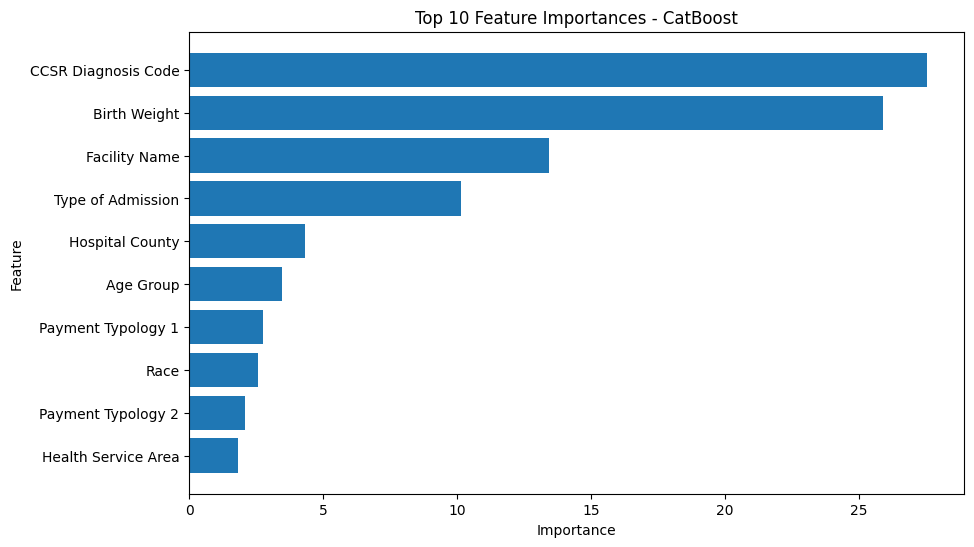

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df.head(10)["Feature"][::-1],
    importance_df.head(10)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - CatBoost")
plt.show()

---

## 14. Results & Discussion

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | *(see Sec 11)* | | |
| Random Forest | | | |
| XGBoost | | | |
| **CatBoost** | **3.7721** | **7.8920** | **0.2092** |

**CatBoost performed best** — lowest MAE/RMSE, highest R² — due to native handling of
high-cardinality categorical codes and ordered boosting.

R² ≈ **0.21** means only a modest share of LOS variance is explained  expected for this task,
since real-world LOS depends on factors not in this dataset (clinical notes, bed availability,
complications). Reported honestly rather than overstated.


## 15. Limitations

1. **Sampling** — RF/XGBoost/CatBoost trained on a 200k-row subsample, not full data.
2. **Moderate R²** — most variance unexplained; use as decision support, not precise forecast.
3. **Top-coded target** — stays ≥120 days collapsed to `120`.
4. **No hyperparameter search** — settings are manual, not tuned.
5. **Single train/test split** — no cross-validation.
6. **Generalizability** — dataset reflects one state/period; may not transfer elsewhere.


## 16. Conclusion & Future Work

Built an end-to-end, leakage-free LOS regression pipeline. **CatBoost was the strongest model**,
benefiting from native categorical handling.

**Future work:**
- Train on full data (or GPU/out-of-core); re-check performance.
- k-fold CV + hyperparameter search (`RandomizedSearchCV`, Optuna).
- Frame LOS as bucketed/ordinal classes (short/medium/long).
- Add richer features (comorbidities, vitals, prior admissions).
- Deploy pipeline behind an API/dashboard with drift monitoring.


## 17. References

1. NYS Dept. of Health — SPARCS De-Identified Hospital Inpatient Discharge Data, Health Data NY.
2. Pedregosa et al., *Scikit-learn*, JMLR, 2011.
3. Chen & Guestrin, *XGBoost*, KDD, 2016.
4. Prokhorenkova et al., *CatBoost*, NeurIPS, 2018.
5. scikit-learn docs — https://scikit-learn.org/stable/
6. XGBoost docs — https://xgboost.readthedocs.io/
7. CatBoost docs — https://catboost.ai/docs/
